<a href="https://colab.research.google.com/github/Leo-Santos17/Big-Data_PowerFit/blob/dev/BigData_Academia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inicialização

In [1]:
import pandas as pd
import tensorflow as tf
import sklearn
import numpy as np


In [2]:
pd.__version__, sklearn.__version__, tf.__version__

('2.2.2', '1.6.1', '2.20.0')

In [43]:
from tensorflow.keras.layers import Dense, Dropout, Activation, Input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model, Sequential
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from tensorflow.keras import utils as np_utils
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from math import floor

In [4]:
import gdown

# O link da pasta: https://drive.google.com/drive/folders/ID_DA_PASTA
folder_url = 'https://drive.google.com/drive/folders/136-2N-itYCWcALZGlLEEf0CTabmH7eQm'

# Baixa a pasta recursivamente
gdown.download_folder(folder_url, quiet=False, use_cookies=True)

Retrieving folder contents


Retrieving folder 14m_P_BugAAO4flyNJ4bv7-laxnRTKM_1 Base
Processing file 1Yg97ayXvprm_0KHmdays8nwFKJBC4R0c gym_members_dataset.csv
Processing file 1XXK0A2hceY4hzJ2hujQrhRPVQ3FVoDNM gym_membership.csv
Retrieving folder 1kEl7kLDJunvSCBQ41Kpu2SO0UY7ujomD Catraca
Processing file 174rVT6smt7sONx4o9SBHlieQ6C5UI121 Ago-Set.csv
Processing file 1tsjyhYeOj6jUTXzDG0USrwypixLi3HDY Dec-Jan.csv
Processing file 1ddc-aCeFCGOHsCk9eygui5nIDGA-Avqp Fev-Marc.csv
Processing file 1lHpwl-5RT9whH7VUob1fCY5U84FWCfg9 Jan-Fev.csv
Processing file 1JpSj2frqPqm7qW1w46VI9IRtXFaSgWoX Jul-Ago.csv
Processing file 1HmZ9NrHMGzWpx4d0NTTQI8mOipoP5j5_ Jun-Jul.csv
Processing file 1fO1bdh5a2w9F7N4a1UrKhIxXqAYj7i_z Mai-Jun.csv
Processing file 1yKaLEIw6UaaidLnnhQrhi4jhhQVPcAKc Mar-Abrl.csv
Processing file 1AuFIeOKB8rIUoS6iL4xACiYs5Xm6f3Ey Nov-Dec.csv
Processing file 1GDCUzWDTYzR8aXrJUXQnUTHiSzxCTgzh Outu-Nov.csv
Processing file 127huiyM8Lfz9WZC498-r4CMWtMc-Vd4M Set-Outu.csv
Retrieving folder 1i5m8K2FvL3xZkxUhnG9CXoQBWTmDSIu1 In

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Yg97ayXvprm_0KHmdays8nwFKJBC4R0c
To: /content/BigData/Base/gym_members_dataset.csv
100%|██████████| 17.9k/17.9k [00:00<00:00, 8.18MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XXK0A2hceY4hzJ2hujQrhRPVQ3FVoDNM
To: /content/BigData/Base/gym_membership.csv
100%|██████████| 115k/115k [00:00<00:00, 2.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=174rVT6smt7sONx4o9SBHlieQ6C5UI121
To: /content/BigData/Catraca/Ago-Set.csv
100%|██████████| 5.97k/5.97k [00:00<00:00, 14.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tsjyhYeOj6jUTXzDG0USrwypixLi3HDY
To: /content/BigData/Catraca/Dec-Jan.csv
100%|██████████| 4.65k/4.65k [00:00<00:00, 4.37MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ddc-aCeFCGOHsCk9eygui5nIDGA-Avqp
To: /content/BigData/Catraca/Fev-Marc.csv
100%|██████████| 5.24k/5.24k [00:00<

['/content/BigData/Base/gym_members_dataset.csv',
 '/content/BigData/Base/gym_membership.csv',
 '/content/BigData/Catraca/Ago-Set.csv',
 '/content/BigData/Catraca/Dec-Jan.csv',
 '/content/BigData/Catraca/Fev-Marc.csv',
 '/content/BigData/Catraca/Jan-Fev.csv',
 '/content/BigData/Catraca/Jul-Ago.csv',
 '/content/BigData/Catraca/Jun-Jul.csv',
 '/content/BigData/Catraca/Mai-Jun.csv',
 '/content/BigData/Catraca/Mar-Abrl.csv',
 '/content/BigData/Catraca/Nov-Dec.csv',
 '/content/BigData/Catraca/Outu-Nov.csv',
 '/content/BigData/Catraca/Set-Outu.csv',
 '/content/BigData/Instrutor/Ago-Out.csv',
 '/content/BigData/Instrutor/Fev-Abr.csv',
 '/content/BigData/Instrutor/Mai-Jul.csv',
 '/content/BigData/Instrutor/Nov-Jan.csv',
 '/content/BigData/Presenca/Abri_2025.xlsx',
 '/content/BigData/Presenca/Ago-Outu.xlsx',
 '/content/BigData/Presenca/Fev-Abr.xlsx',
 '/content/BigData/Presenca/Mai-Jul.xlsx',
 '/content/BigData/Presenca/Nov-Jan.xlsx',
 '/content/BigData/Base-Clientes.csv',
 '/content/BigData/Cl

# Tratar

## Importar/Adicionar

## Clientes

In [5]:
clientes = pd.read_csv('/content/BigData/Base-Clientes.csv')
clientes['Data de nascimento'] = pd.to_datetime(clientes['Data de nascimento'], errors='coerce')
clientes

,Nome,Contrato,Situação do contrato,Situação do cliente,Data de nascimento,Data de cadastro,Objetivo,Sexo,VIP,Consultor,Professor
0,ABEL THALISON SILVA LOBATO,DIÁRIA,Encerrado,Inativo,2005-05-21 02:59:32,08/31/2023 03:06:45,Hipertrofia,Masculino,Não,NaN,NaN
1,ABNER DA SILVA CABRAL NETO,PLANO FUNCIONÁRIO PÚBLICO,Encerrado,Inativo,1992-05-18 02:59:32,08/03/2024 03:01:01,NaN,Masculino,Não,ACADEMIA,ACADEMIA
2,ABRAÃO DA SILVA BENTO,PLANO POWER GYM TOP,Encerrado,Inativo,1988-02-12 02:59:32,09/08/2025 03:52:12,NaN,Masculino,Não,ACADEMIA,NaN
3,ABRAÃO MAGALHÃES,PLANO POWER GYM TOP,Encerrado,Inativo,2000-02-09 01:59:32,02/10/2025 03:32:40,NaN,Masculino,Não,ACADEMIA,ACADEMIA
4,ADAILSE DE JESUS MONTEIRO,PLANO POWER GYM TOP,Encerrado,Inativo,1975-01-27 02:59:32,11/06/2023 03:40:57,Hipertrofia,Feminino,Não,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4572,renata freitas silva,PLANO POWER GYM TOP,Encerrado,Inativo,2000-01-20 01:59:32,07/05/2025 03:42:26,NaN,Feminino,Não,ACADEMIA,NaN
4573,rg,NaN,Encerrado,Inativo,1990-01-01 01:59:32,06/05/2023 03:33:44,NaN,Masculino,Não,NaN,NaN
4574,teste 3,AVALIAÇÃO FÍSICA (BIOIMPEDÂNCIA),Encerrado,Inativo,1991-09-27 02:59:32,02/01/2024 03:39:00,NaN,Masculino,Não,CARLOS EDUARDO,CARLOS EDUARDO
4575,teste 5,DIÁRIA,Encerrado,Inativo,2024-05-03 02:59:32,05/04/2024 03:16:52,NaN,Masculino,Não,ACADEMIA,ACADEMIA


In [6]:
# 3. Criar a função para calcular idade
def calcular_idade(nascimento):
    if pd.isnull(nascimento):
        return None
    hoje = datetime.now()
    # Subtrai os anos e ajusta se o aniversário ainda não ocorreu no ano atual
    return hoje.year - nascimento.year - ((hoje.month, hoje.day) < (nascimento.month, nascimento.day))

# 4. Aplicar e criar a nova coluna
clientes['Idade'] = clientes['Data de nascimento'].apply(calcular_idade)

## Catraca

In [7]:
base1 = pd.read_excel('/content/BigData/Presenca/Abri_2025.xlsx')
base2 = pd.read_excel('/content/BigData/Presenca/Ago-Outu.xlsx')
base3 = pd.read_excel('/content/BigData/Presenca/Fev-Abr.xlsx')
base4 = pd.read_excel('/content/BigData/Presenca/Mai-Jul.xlsx')
base5 = pd.read_excel('/content/BigData/Presenca/Nov-Jan.xlsx')

In [8]:
base = pd.concat([base1,base2,base3,base4,base5], keys=['Nome', 'Data', 'Contrato'])

/tmp/ipykernel_20915/4186598270.py:1: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  base = pd.concat([base1,base2,base3,base4,base5], keys=['Nome', 'Data', 'Contrato'])


In [9]:
# 1. Garante que as colunas de união são strings puras
base['Nome'] = base['Nome'].astype(str)
clientes['Nome'] = clientes['Nome'].astype(str)

# 2. Faz o merge garantindo a tabela da esquerda (df1) como base
# Vamos trazer apenas a coluna 'sexo' da df2 para não poluir
base = base.merge(clientes[['Nome', 'Sexo']], on='Nome', how='left')

base

,Nome,Contrato,Data,Sexo
0,ROBERT RODRIGO CARLOS CARNEIRO,PLANO POWER GYM TOP,30/04/2025 21:07,Masculino
1,JESSICA OLIVEIRA CORREA,PLANO POWER GYM TOP,30/04/2025 21:06,Feminino
2,RENAN DA SILVA MATNI,PLANO POWER GYM TOP,30/04/2025 20:58,Masculino
3,CARLOS VINICIUS DAMASCENOS MAGALHÃES,PLANO POWER GYM TOP,30/04/2025 20:48,Masculino
4,BRENDA CRYSTINA DE ARAUJO SILVA,PLANO FUNCIONÁRIO PÚBLICO,30/04/2025 20:48,Feminino
...,...,...,...,...
40363,BARBARA MAISA NUNES ARAUJO,PLANO POWER GYM TOP,02/02/2026 06:12,Feminino
40364,KETLEN BEATRIZ CORREIA DA SILVA,MUSCULAÇÃO PLANO FAMILIA,02/02/2026 06:11,Feminino
40365,ANTONIO CARLOS MARINHO PAIVA,PLANO FUNCIONÁRIO PÚBLICO,02/02/2026 06:09,Masculino
40366,ANA PAULA PINTO DA SILVA,PLANO POWER GYM TOP,02/02/2026 06:09,Feminino


In [10]:
# Converte a coluna para o formato de data real
base['Data'] = pd.to_datetime(base['Data'])

# Agora a ordenação funcionará perfeitamente
base = base.sort_values(by='Data')

/tmp/ipykernel_20915/45498016.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  base['Data'] = pd.to_datetime(base['Data'])


In [11]:
base

,Nome,Contrato,Data,Sexo
7033,VERLANE GOMES DE LIIMA,PLANO POWER GYM TOP,2025-04-01 06:03:00,Feminino
7032,MOIZES DA CUNHA GONÇALVES,PLANO POWER GYM TOP,2025-04-01 06:05:00,Masculino
7031,GEOVANA FERREIRA DA SILVA,PLANO POWER GYM TOP,2025-04-01 06:05:00,Feminino
7030,AMANDA ALVES E SILVA,PLANO POWER GYM TOP,2025-04-01 06:06:00,Feminino
7029,ROBERTO DO SOCORRO BENVINDO AVILA,PLANO POWER GYM TOP,2025-04-01 06:10:00,Masculino
...,...,...,...,...
27037,ROBERTA ESTER SOARES NASCIMENTO,PLANO POWER GYM TOP,2026-04-14 14:14:00,Feminino
27036,FELIPE FERREIRA DA SILVA,PLANO POWER GYM TOP,2026-04-14 14:16:00,Masculino
27035,KARINA GUADAMIM FERNANDES,PLANO POWER GYM TOP,2026-04-14 14:16:00,Feminino
27034,ANTONYONE DE OLIVEIRA UCHOUA,MUSCULAÇÃO PLANO FAMILIA,2026-04-14 14:17:00,Masculino


## Limpar

In [12]:
base = base.drop(["Contrato"], axis=1)

In [13]:
base

,Nome,Data,Sexo
7033,VERLANE GOMES DE LIIMA,2025-04-01 06:03:00,Feminino
7032,MOIZES DA CUNHA GONÇALVES,2025-04-01 06:05:00,Masculino
7031,GEOVANA FERREIRA DA SILVA,2025-04-01 06:05:00,Feminino
7030,AMANDA ALVES E SILVA,2025-04-01 06:06:00,Feminino
7029,ROBERTO DO SOCORRO BENVINDO AVILA,2025-04-01 06:10:00,Masculino
...,...,...,...
27037,ROBERTA ESTER SOARES NASCIMENTO,2026-04-14 14:14:00,Feminino
27036,FELIPE FERREIRA DA SILVA,2026-04-14 14:16:00,Masculino
27035,KARINA GUADAMIM FERNANDES,2026-04-14 14:16:00,Feminino
27034,ANTONYONE DE OLIVEIRA UCHOUA,2026-04-14 14:17:00,Masculino


## Corrigir

In [14]:
base = base[base['Nome'] != 'CANCELADO']
base = base[base['Nome'] != 'diaria 7']

In [15]:
base.isnull().sum()

,0
Nome,0
Data,0
Sexo,24


In [16]:
base.loc[base['Sexo'].isna(), ['Nome', 'Data']]

,Nome,Data
26254,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-05 14:54:00
26239,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-05 15:36:00
25958,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-06 14:40:00
25619,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-07 13:48:00
25618,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-07 13:48:00
24930,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-11 14:02:00
24615,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-12 14:22:00
24335,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-13 13:31:00
24002,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-14 14:02:00
23446,LUIZ HENRIQUE SOUSA DE ALENCAR,2025-08-18 14:22:00


In [17]:
base = base.fillna(value = {"Sexo": "Masculino"})

# Treino

## Criação Tabela

In [18]:
# Definindo a data de referência (último dia do seu dataset)
data_referencia = base['Data'].max()

In [19]:
# Agrupando para criar as colunas de comportamento
treino_comportamento = base.groupby('Nome').agg(
    Total_Visitas=('Data', 'count'),
    Ultima_Visita=('Data', 'max')
).reset_index()

In [20]:
# Calculando a Recência (Dias sem ir)
treino_comportamento['Dias_Sem_Ir'] = (data_referencia - treino_comportamento['Ultima_Visita']).dt.days

In [21]:
# Unindo com os dados de perfil que você já tratou na variável 'clientes'
# Vamos trazer Idade e Sexo
df_treino = treino_comportamento.merge(clientes[['Nome', 'Sexo', 'Idade']], on='Nome', how='inner')

In [22]:
# Criando o TARGET (Churn): 1 se não vai há mais de 30 dias, 0 se é frequente
df_treino['Churn'] = df_treino['Dias_Sem_Ir'].apply(lambda x: 1 if x > 30 else 0)

In [23]:
df_treino

,Nome,Total_Visitas,Ultima_Visita,Dias_Sem_Ir,Sexo,Idade,Churn
0,ABEL THALISON SILVA LOBATO,1,2025-09-24 16:39:00,201,Masculino,20,1
1,ABNER DA SILVA CABRAL NETO,5,2025-04-07 16:43:00,371,Masculino,33,1
2,ABRAÃO DA SILVA BENTO,3,2025-09-12 19:13:00,213,Masculino,38,1
3,ADALTON RODRIGUES DA SILVA,71,2026-04-09 18:10:00,4,Masculino,36,0
4,ADAM WESLEY DUARTE,58,2026-04-09 18:42:00,4,Masculino,16,0
...,...,...,...,...,...,...,...
1370,karen kayane pereira dias,8,2025-10-28 06:09:00,168,Feminino,29,1
1371,kaue cunha nunes,2,2025-08-27 19:29:00,229,Masculino,22,1
1372,marcia roberta pereira braga,21,2025-10-28 20:06:00,167,Feminino,30,1
1373,maria camila alvez de souza,11,2025-09-18 19:27:00,207,Feminino,31,1


## Preparação

In [24]:
# Transformando Sexo em número (0 e 1)
le = LabelEncoder()
df_treino['Sexo'] = le.fit_transform(df_treino['Sexo'].astype(str))

In [25]:
# Removendo colunas que não são números (Nome e Datas)
# O modelo não pode saber o Nome, senão ele decora o aluno em vez de aprender o padrão
X = df_treino[['Total_Visitas', 'Idade', 'Sexo']].values
y = df_treino['Churn'].values

In [26]:
# Dividindo entre treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
df_treino

,Nome,Total_Visitas,Ultima_Visita,Dias_Sem_Ir,Sexo,Idade,Churn
0,ABEL THALISON SILVA LOBATO,1,2025-09-24 16:39:00,201,1,20,1
1,ABNER DA SILVA CABRAL NETO,5,2025-04-07 16:43:00,371,1,33,1
2,ABRAÃO DA SILVA BENTO,3,2025-09-12 19:13:00,213,1,38,1
3,ADALTON RODRIGUES DA SILVA,71,2026-04-09 18:10:00,4,1,36,0
4,ADAM WESLEY DUARTE,58,2026-04-09 18:42:00,4,1,16,0
...,...,...,...,...,...,...,...
1370,karen kayane pereira dias,8,2025-10-28 06:09:00,168,0,29,1
1371,kaue cunha nunes,2,2025-08-27 19:29:00,229,1,22,1
1372,marcia roberta pereira braga,21,2025-10-28 20:06:00,167,0,30,1
1373,maria camila alvez de souza,11,2025-09-18 19:27:00,207,0,31,1


In [57]:
X_train.shape, X_test.shape

(1100, 3)

## Scaler

In [31]:
# 3. Scaling (O segredo para não "viciar" nos números grandes)
scaler = StandardScaler()

In [32]:
# Ajustamos o scaler APENAS nos dados de treino para evitar data leakage
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
# Aplicamos a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_scaled

array([[-0.63612461, -0.8745129 ,  1.05419371],
       [-0.54828783,  0.41055377, -0.94859227],
       [-0.75324031, -1.14988433,  1.05419371],
       ...,
       [-0.40189319, -0.14018909,  1.05419371],
       [ 1.06205314,  1.0530871 , -0.94859227],
       [-0.37261427, -0.69093195, -0.94859227]])

## Train

In [64]:
unit_train = floor((X_train.shape[1] + 1)/2)
unit_train2 = floor(unit_train/2)
model = Sequential([
    Input(shape=(X_train.shape[1],)), # Entrada: Total_Visitas, Idade, Sexo
    Dense(64, activation='relu'),      # Camada oculta 1
    Dropout(0.2),                     # Evita que o modelo decore os dados (overfitting)
    Dense(32, activation='relu'),       # Camada oculta 2
    Dense(1, activation='sigmoid')     # Saída: Probabilidade de Churn (0 a 1)
])

In [65]:
# Compilação
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,              # Quantas vezes ele vai ler o dataset
    batch_size=32,           # Quantos alunos ele olha por vez antes de ajustar os pesos
    validation_split=0.2,    # Reserva 20% do treino para validação em tempo real
    verbose=1
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7523 - loss: 0.5165 - val_accuracy: 0.7909 - val_loss: 0.5060
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7409 - loss: 0.5221 - val_accuracy: 0.7909 - val_loss: 0.5044
Epoch 3/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7523 - loss: 0.5153 - val_accuracy: 0.7773 - val_loss: 0.5080
Epoch 4/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7545 - loss: 0.5156 - val_accuracy: 0.7773 - val_loss: 0.5120
Epoch 5/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7557 - loss: 0.5167 - val_accuracy: 0.7864 - val_loss: 0.5065
Epoch 6/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5104 - val_accuracy: 0.7727 - val_loss: 0.5155
Epoch 7/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7545 - loss: 0.5172 - val_accuracy: 0.7773 - val_loss: 0.5149
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7523 - loss: 0.5143 - val_accuracy: 0.777

# Matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

       Ativo       0.66      0.63      0.65       109
       Churn       0.77      0.79      0.78       166

    accuracy                           0.73       275
   macro avg       0.71      0.71      0.71       275
weighted avg       0.73      0.73      0.73       275



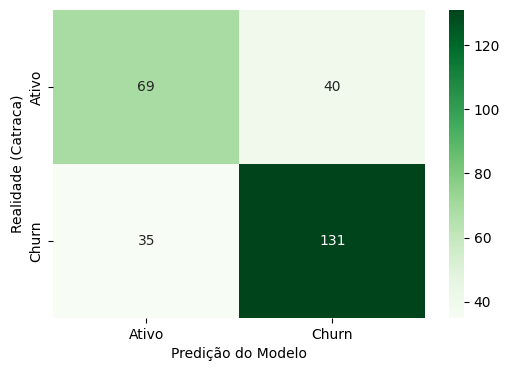

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prever as classes (0 ou 1) usando o limiar de 0.5
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

# 2. Relatório de métricas (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=['Ativo', 'Churn']))

# 3. Visualizar a Matriz
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ativo', 'Churn'], yticklabels=['Ativo', 'Churn'])
plt.xlabel('Predição do Modelo')
plt.ylabel('Realidade (Catraca)')
plt.show()